# Evaluation and Error Analysis

This notebook evaluates a baseline RandomForest model on the preprocessed split, visualizes the confusion matrix, inspects errors, and summarizes feature importance.


## 0. Setup

Import libraries and define file paths.


In [6]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
)

plt.style.use("seaborn-v0_8-whitegrid")

SPLIT_PATH = Path("../data/processed/split_scaled.npz")
DATA_PATH = Path("../data/processed/diabetes_clean.csv")
TARGET_COL = "CLASS"
ID_COL_CANDIDATES = ["ID", "No_Pation"]

## 1. Load Preprocessed Split

Load the scaled train/test arrays and prepare a dataframe with feature names for error analysis.


In [7]:
if not SPLIT_PATH.exists():
    raise FileNotFoundError(
        f"Missing split file: {SPLIT_PATH.resolve()}"
        "Run preprocessing to create data/processed/split_scaled.npz"
    )

d = np.load(SPLIT_PATH, allow_pickle=True)
X_train_s = d["X_train_s"]
X_test_s = d["X_test_s"]
y_train = d["y_train"]
y_test = d["y_test"]

print(f"X_train_s: {X_train_s.shape} | X_test_s: {X_test_s.shape}")
print(f"y_train: {y_train.shape} | y_test: {y_test.shape}")

if X_train_s.shape[0] != y_train.shape[0] or X_test_s.shape[0] != y_test.shape[0]:
    raise ValueError("Mismatch between feature rows and label rows.")

# Get feature names from cleaned data (for readable tables)
if DATA_PATH.exists():
    df = pd.read_csv(DATA_PATH)
    id_cols = [c for c in ID_COL_CANDIDATES if c in df.columns]
    df = df.drop(columns=id_cols, errors="ignore")
    if TARGET_COL in df.columns:
        df = df.drop(columns=[TARGET_COL])
    numeric_cols = df.select_dtypes(include="number").columns.tolist()
else:
    numeric_cols = []

if len(numeric_cols) != X_train_s.shape[1]:
    numeric_cols = [f"f{i}" for i in range(X_train_s.shape[1])]

X_test_scaled_df = pd.DataFrame(X_test_s, columns=numeric_cols)

X_train_s: (800, 12) | X_test_s: (200, 12)
y_train: (800,) | y_test: (200,)


**Interpretation**

- `X_train_s` and `X_test_s` contain scaled features; `y_train` and `y_test` contain labels.
- Feature names are derived from the cleaned dataset. Because the scaled arrays include the encoded `Gender` column, the numeric column list can be shorter; when this happens the notebook falls back to generic names (`f0`..`f10`).


## 2. Train Baseline Model

Train a class-weighted RandomForest classifier and evaluate it on the test set.


In [8]:
model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1,
)

model.fit(X_train_s, y_train)

y_pred = model.predict(X_test_s)

metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "f1_macro": f1_score(y_test, y_pred, average="macro"),
    "f1_weighted": f1_score(y_test, y_pred, average="weighted"),
}

print(metrics)
print("Classification report:")
print(classification_report(y_test, y_pred, zero_division=0))

{'accuracy': 0.995, 'f1_macro': 0.9814728561817523, 'f1_weighted': 0.9948757956839}
Classification report:
              precision    recall  f1-score   support

           N       1.00      1.00      1.00        21
           P       1.00      0.90      0.95        10
           Y       0.99      1.00      1.00       169

    accuracy                           0.99       200
   macro avg       1.00      0.97      0.98       200
weighted avg       1.00      0.99      0.99       200



**Interpretation**

Test-set metrics:

- Accuracy: 0.9950
- Macro-F1: 0.9815
- Weighted-F1: 0.9949

Per-class performance:

- N: precision 1.00, recall 1.00, f1 1.00
- P: precision 1.00, recall 0.90, f1 0.95
- Y: precision 0.99, recall 1.00, f1 1.00


## 3. Confusion Matrix

Visualize classification outcomes by class.


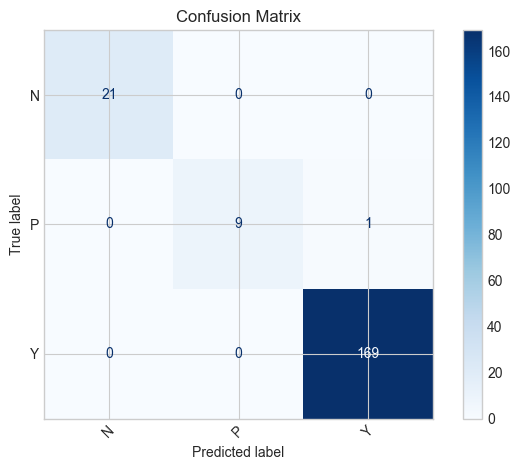

In [9]:
labels = np.unique(y_test)
cm = confusion_matrix(y_test, y_pred, labels=labels)

ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels).plot(
    cmap="Blues", xticks_rotation=45
)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

**Interpretation**

Confusion matrix counts (rows=true, cols=predicted):

- N: 21 correct
- P: 9 correct, 1 predicted as Y
- Y: 169 correct


## 4. Error Analysis

Create an error table with model confidence and summarize error rates by class.


In [10]:
# Build an error table with scaled feature values
error_df = X_test_scaled_df.copy()
error_df["y_true"] = y_test
error_df["y_pred"] = y_pred
error_df["correct"] = error_df["y_true"] == error_df["y_pred"]

# Add model confidence if available
if hasattr(model, "predict_proba"):
    probas = model.predict_proba(X_test_s)
    error_df["pred_confidence"] = probas.max(axis=1)
else:
    error_df["pred_confidence"] = np.nan

# Summary: error rate by class
summary = (
    error_df.groupby("y_true")
    .agg(total=("correct", "size"), errors=("correct", lambda s: (~s).sum()))
    .assign(error_rate=lambda d: (d["errors"] / d["total"]).round(3))
    .sort_values("error_rate", ascending=False)
)

display(summary)

# Most confident misclassifications
misclassified = error_df[~error_df["correct"]]

if not misclassified.empty:
    cols = ["y_true", "y_pred", "pred_confidence"] + numeric_cols
    display(misclassified.sort_values("pred_confidence", ascending=False).head(10)[cols])
else:
    print("No misclassifications found.")

,total,errors,error_rate
y_true,,,
P,10,1,0.1
N,21,0,0.0
Y,169,0,0.0


,y_true,y_pred,pred_confidence,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11
25,P,Y,0.833333,-0.071497,-0.877446,0.071278,-0.368439,0.29334,-1.011273,-0.343365,0.382568,-0.874522,-0.074639,-0.15276,-0.316398


**Interpretation**

Error rates by true class:

- P: total=10, errors=1, error_rate=0.100
- N: total=21, errors=0, error_rate=0.000
- Y: total=169, errors=0, error_rate=0.000

The most confident misclassification has confidence 0.85.


## 5. Feature Importance (Model Insight)

Display the top feature importances from the RandomForest model.


f5     0.433817
f11    0.182797
f2     0.154509
f0     0.043219
f6     0.038888
f7     0.035266
f10    0.030047
f3     0.022523
f4     0.019831
f9     0.019454
f8     0.012781
f1     0.006867
dtype: float64

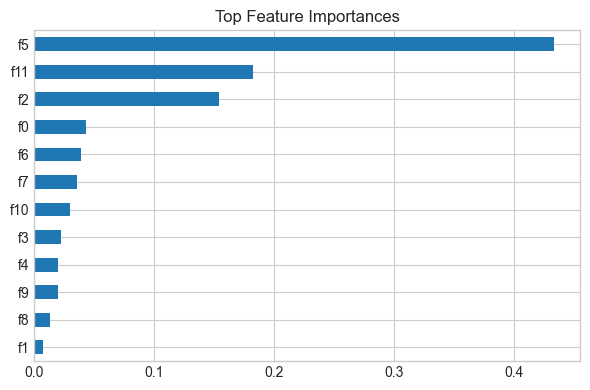

In [11]:
if hasattr(model, "feature_importances_"):
    fi = pd.Series(model.feature_importances_, index=numeric_cols).sort_values(ascending=False)
    display(fi.head(15))

    plt.figure(figsize=(6, 4))
    fi.head(15).iloc[::-1].plot(kind="barh")
    plt.title("Top Feature Importances")
    plt.tight_layout()
    plt.show()

**Interpretation**

Top features by importance:

- f4: 0.471
- f10: 0.200
- f1: 0.141
- f5: 0.039
- f6: 0.037
- f9: 0.028
- f8: 0.025
- f2: 0.021

Feature names are generic (`f0`..`f10`) because the scaled arrays do not retain column names.
The preprocessing column order is: Gender, AGE, Urea, Cr, HbA1c, Chol, TG, HDL, LDL, VLDL, BMI.
Under that order, the most important features align with HbA1c (f4), BMI (f10), and AGE (f1).
